<a href="https://colab.research.google.com/github/suryasai99/Object_detection/blob/main/10_custom_dataloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import requests
from zipfile import ZipFile

In [2]:
# Uncomment the following line if you are using Colab.
!pip install -qU albumentations --no-binary qudida albumentations

In [3]:
def download_file(url, save_name):
    """
    "Download and save the file."

    arguments:
    url (str): URL path of the file.
    save_name: (str): file path to save the downloaded file.
    """
    file = requests.get(url)
    open(save_name, 'wb').write(file.content)
    print(f"Downloaded {save_name}...")
    return

In [4]:
def unzip(zip_file_path = None):
    """
    "Unzip the file"

    arguments:
    zip_file_path (str): The zipped file path

    """
    try:
        with ZipFile(zip_file_path) as z:
            z.extractall("./")
            print(f"Extracted {zip_file_path}...\n")
    except:
        print("Invalid file")

    return

In [5]:
if not os.path.exists('data-PennFudanPed'):
    download_file(
                  'https://www.dropbox.com/s/mnngpxz3bjeb31a/PennFudanPed.zip?dl=1',
                  'PennFudanPed.zip'
                 )

    unzip('PennFudanPed.zip')


if not os.path.exists('./encoder.py'):
    download_file(
                  'https://www.dropbox.com/s/m1dod6hyaup6o7m/encoder_decoder.zip?dl=1',
                  'encoder_decoder.zip'
                 )

    unzip('encoder_decoder.zip')

Downloaded PennFudanPed.zip...
Extracted PennFudanPed.zip...



In [6]:
os.listdir("./")

['.config',
 'encoder_decoder.zip',
 'train_boxes.csv',
 'encoder.py',
 '__pycache__',
 'PennFudanPed',
 'PennFudanPed.zip',
 'sample_data']

In [7]:
import cv2
import random
import numpy as np

import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

import torch
from encoder import DataEncoder
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

In [8]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 10)

In [9]:
def set_seeds():
    # fix random seeds
    SEED_VALUE = 42

    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE)
        torch.cuda.manual_seed_all(SEED_VALUE)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True


set_seeds()

## Create a custom Dataset Class

In [10]:
def load_groundtruths(filepath = "valid_anno.txt",
                      shuffle = True):
    image_paths = []
    boxes = []
    labels = []

    with open(filepath) as f:
        lines = f.readlines()
        num_samples = len(lines)

    total_boxes = 0

    for line in lines:
        splited = line.strip().split()
        image_paths.append(splited[0])
        num_boxes = (len(splited) - 1) // 5
        total_boxes += num_boxes

        box = []
        label = []

        for i in range(num_boxes):
            xmin = splited[1 + 5 * i]
            ymin = splited[2 + 5 * i]
            xmax = splited[3 + 5 * i]
            ymax = splited[4 + 5 * i]
            class_label = int(splited[5 + 5 * i])
            box.append([float(xmin), float(ymin),
                        float(xmax), float(ymax)])
            label.append(class_label)

        boxes.append(box)
        labels.append(label)

    print(f"Total {num_samples} images and {total_boxes} boxes loaded from {os.path.relpath(filepath, os.getcwd())}")

    # shuffle or sort
    if shuffle:
        temp = list(zip(image_paths, boxes, labels))
        random.shuffle(temp)
        image_paths, boxes, labels = zip(*temp)
    else:
        image_paths, boxes, labels = zip(*sorted(zip(image_paths, boxes, labels)))

    image_paths = list(image_paths)
    boxes = list(boxes)
    labels = list(labels)

    return image_paths, boxes, labels, num_samples

In [11]:
class ListDataset(Dataset):
    def __init__(self, root_dir,
                 list_file, classes,
                 transform = None, is_train = True,
                 input_size = (300, 300, 3)):

        self.root_dir = os.path.expanduser(root_dir)
        self.list_file = list_file
        self.classes = classes
        self.transforms = transform
        self.input_size = input_size
        self.is_train = is_train
        self.encoder = DataEncoder(self.input_size[:2], self.classes)
        self.list_file_path = os.path.join(self.root_dir, self.list_file)
        self.image_paths, self.boxes, self.labels, self.num_samples = \
                                        load_groundtruths(filepath = self.list_file_path, shuffle = True)

    def __len__(self):
        # Get size of the dataset
        return self.num_samples

    def  __getitem__(self, idx):

        image_path = self.image_paths[idx]
        indexed_boxes = self.boxes[idx]
        indexed_labels = self.labels[idx]

        img = cv2.cvtColor(cv2.imread(os.path.join(self.root_dir, image_path)), cv2.COLOR_BGR2RGB)

        if self.transforms:
            transformed = self.transforms(image = img, bboxes = indexed_boxes,
                                          category_ids = indexed_labels)

        else: # Mandatory transforms to be applied
            common_transforms = A.Compose(
                                [A.Resize(
                                        height=self.input_size[0], width=self.input_size[1],
                                        interpolation=4, always_apply=True
                                       ),
                                ToTensorV2()],
                                bbox_params=A.BboxParams(format="pascal_voc", label_fields=["category_ids"])
                                )

            transformed = common_transforms(image = img, bboxes = indexes_boxes,
                                            category_ids = indexed_labels)

        transformed_img = transformed['image']
        transformed_boxes = transformed['bboxes']
        transformed_labels = transformed['category_ids']

        transformed_boxes = torch.tensor(transformed_boxes, dtype = torch.float)
        transformed_labels = torch.tensor(transformed_labels, dtype = torch.int)

        loc_target, cls_target = self.encoder.encode(transformed_boxes, transformed_labels)

        return transformed_img, transformed_boxes, transformed_labels, loc_target, cls_target

    def collate_fn(self, batch):
        return list(zip(*batch))



In [12]:
def apply_augmentations(height = 300, width = 300):
    augment = [
        A.Resize(height = height, width = width,
                 interpolation = 4, always_apply = True),
        A.HorizontalFlip(p = 0.5),
        A.ShiftScaleRotate(scale_limit = 0.6, rotate_limit = 0,
                           shift_limit = 0.1, p = 0.5, border_mode = 0,
                           value = 0),
        ToTensorV2()
    ]
    transforms = A.Compose(
        augment,
        bbox_params = A.BboxParams(format = "pascal_voc", label_fields = ["category_ids"])
    )

    return transforms

In [13]:
transforms = apply_augmentations()

/tmp/ipykernel_9500/131784142.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(height = height, width = width,
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_9500/131784142.py:6: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(scale_limit = 0.6, rotate_limit = 0,


In [14]:
dataset = ListDataset(
    root_dir='./PennFudanPed',
    list_file='valid_anno.txt',
    transform=transforms,
    classes    = ("__background__", "person"),
    input_size = (300, 300, 3),
    is_train=False,
)

data_loader = DataLoader(
    dataset, batch_size = 6,
    shuffle = True, num_workers = 0,
    pin_memory = True, collate_fn = dataset.collate_fn
)

Total 30 images and 68 boxes loaded from PennFudanPed/valid_anno.txt


## Visualizing Transformed images

In [15]:
def draw_bbox(image, boxes,
              labels = None, color = (255, 0, 0),
              thickness = -1):
    for idx, box in enumerate(boxes):
        xmin = box[0]
        ymin = box[1]
        xmax = box[2]
        ymax = box[3]

        image = np.ascontiguousarray(image)
        image = cv2.rectangle(image, (xmin, ymin),
                              (xmax, ymax), color,
                              thickness)

        if labels:
            display_text = str(labels[idx])

            (text_width, text_height), _ = cv2.getTextSize(display_text,
                                                           cv2.FONT_HERSHEY_SIMPLEX,
                                                           1.0,
                                                           2)

            cv2.rectangle(image,
                          (xmin, ymin - int(0.9 * text_height)),
                          (xmin + int(0.4 * text_width), ymin),
                          color,
                          -1)

            image = cv2.putText(
                image,
                display_text,
                (xmin, ymin - int(0.3 * text_height)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (0, 0, 0),
                1
            )

    return image

In [16]:
def visualize_transformed_data(images, boxes, labels, classes):

    # Define subplots
    plt.figure(figsize = (20, 15))

    ncols = 3
    nrows = int(np.ceil(len(images)/ncols))

    for batch_id, (img_trans, box_trans, labels) in enumerate(zip(images, boxes, labels)):
        plt.subplot(nrows, ncols, batch_id + 1)
        plt.title("Transformed Image")

        trans_img = np.transpose(img_trans.numpy(),axes = (1, 2, 0)).astype(np.uint8)
        trans_boxes = box_trans.numpy().astype(np.int32)
        trans_labels = labels.numpy().astype(np.int32)

        trans_labels_names = [classes[cls_idx] for cls_idx in trans_labels]

        trans_img_ann = draw_bbox(trans_img, trans_boxes,
                                  labels = trans_labels_names,
                                  color = (0, 255, 0), thickness = 2)

        plt.imshow(trans_img_ann)
        plt.axis("off")


    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images shape: torch.Size([6, 3, 300, 300])
Batch Boxes (encoded) shape: torch.Size([6, 7756, 4])
Batch Labels (encoded) shape: torch.Size([6, 7756])

Batch Boxes (raw) shape: torch.Size([12, 4])
Batch Labels (raw) shape: torch.Size([12])



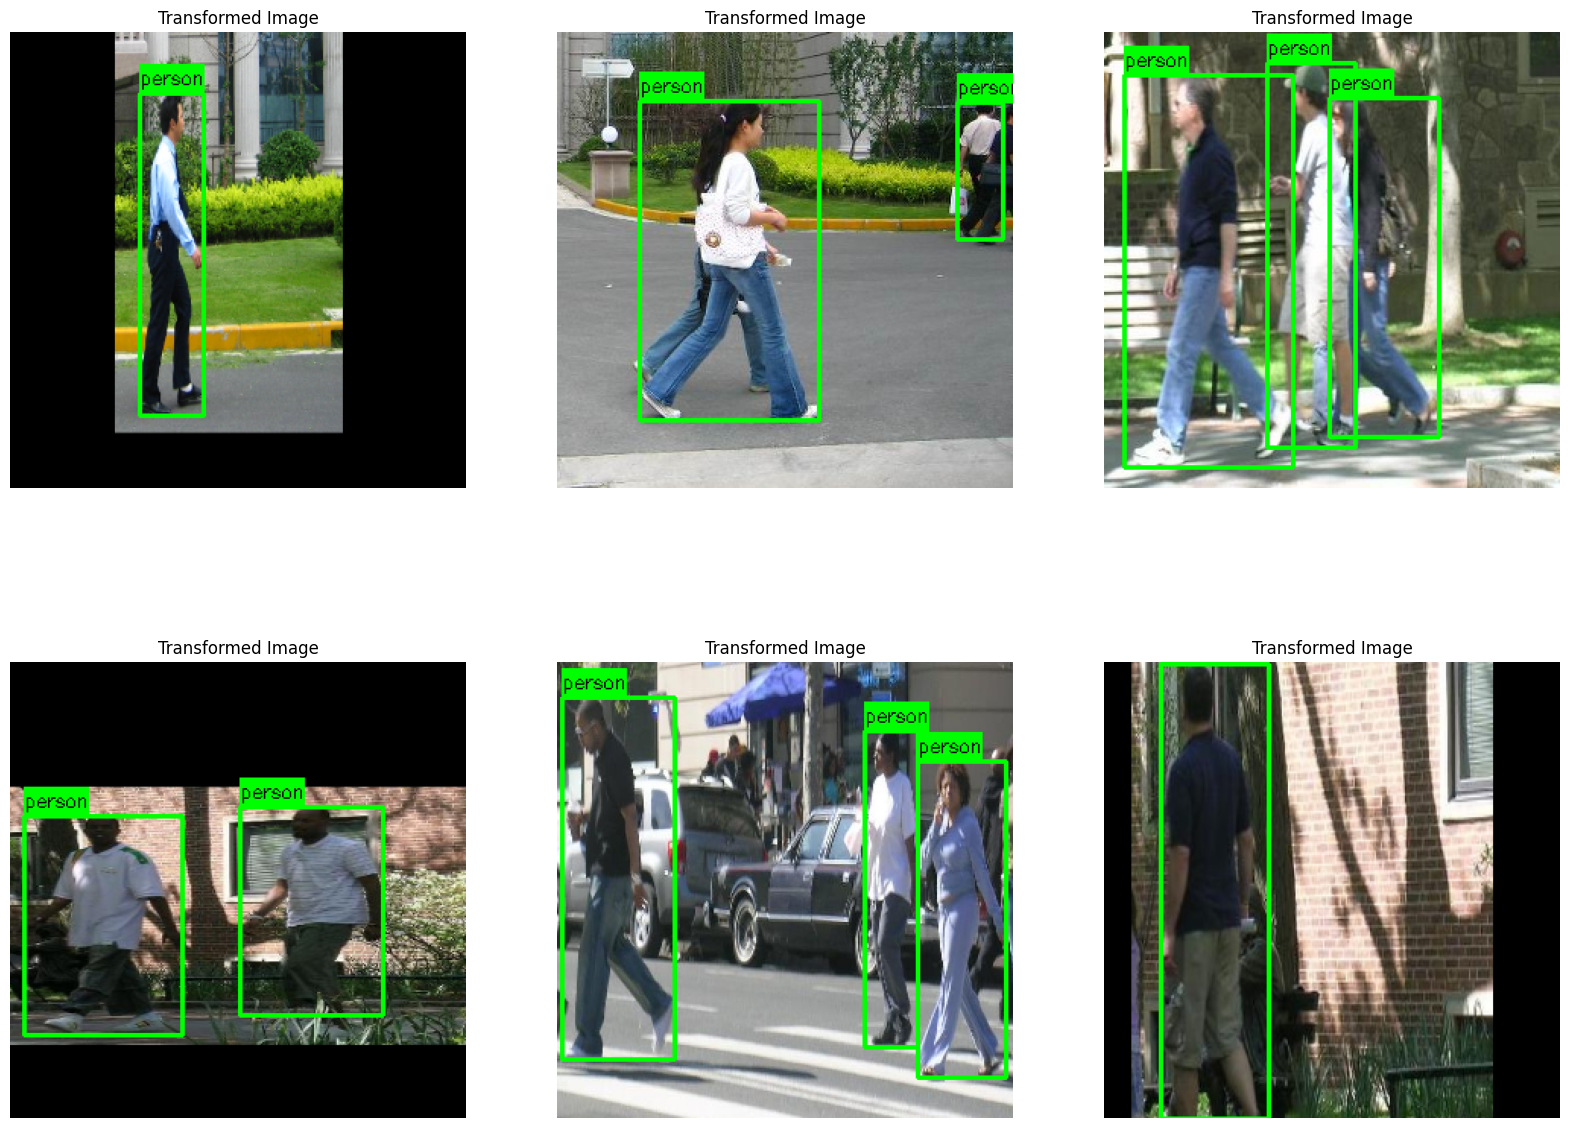

In [17]:
classes = ("__background__", "person")

for i, batch_sample in enumerate(data_loader):
    img_batch = torch.stack(batch_sample[0])
    boxes_raw = torch.cat(batch_sample[1])
    labels_raw = torch.cat(batch_sample[2])

    boxes_encoded = torch.stack(batch_sample[3])
    labels_encoded = torch.stack(batch_sample[4])

    print(f"Images shape: {img_batch.shape}")
    print(f"Batch Boxes (encoded) shape: {boxes_encoded.shape}")
    print(f"Batch Labels (encoded) shape: {labels_encoded.shape}\n")
    print(f"Batch Boxes (raw) shape: {boxes_raw.shape}")
    print(f"Batch Labels (raw) shape: {labels_raw.shape}\n")

    visualize_transformed_data(batch_sample[0], # List of transformed image tensors.
                               batch_sample[1], # List of transformed raw boxes.
                               batch_sample[2], # List of raw labels.
                               classes)

    break